In [1]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.ensemble import VotingClassifier
from sklearn.metrics import accuracy_score

In [2]:
X, y = make_classification(n_samples=500, n_features=2, 
                           n_redundant=0, n_clusters_per_class=1,
                           random_state=42)

In [3]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3)


In [34]:
# 3. Define Models
model1 = LogisticRegression()
model2 = DecisionTreeClassifier(max_depth=5)
model3 = SVC(probability=True)  # needed for soft voting

In [35]:
# 4. Train Individual Models
for model in [model1, model2, model3]:
    model.fit(X_train, y_train)

## Voting Classifiers

In [36]:
## HARD VOTING

In [37]:
hard_vote = VotingClassifier(
    estimators=[('lr', model1), ('dt', model2), ('svm', model3)],
    voting='hard'
)

In [38]:
# SOFT VOTING

In [39]:
soft_vote = VotingClassifier(
    estimators=[('lr', model1), ('dt', model2), ('svm', model3)],
    voting='soft'
)

In [40]:
# WEIGHTED VOTING

In [41]:
weighted_vote = VotingClassifier(
    estimators=[('lr', model1), ('dt', model2), ('svm', model3)],
    voting='soft',
    weights=[1,5,1]   # giving more importance to LR
)

In [42]:
## TRAIN ENSEMBLE

In [43]:
hard_vote.fit(X_train, y_train)
soft_vote.fit(X_train, y_train)
weighted_vote.fit(X_train, y_train)

,"estimators estimators: list of (str, estimator) tuplesInvoking the ``fit`` method on the ``VotingClassifier`` will fit clonesof those original estimators that will be stored in the class attribute``self.estimators_``. An estimator can be set to ``'drop'`` using:meth:`set_params`... versionchanged:: 0.21 ``'drop'`` is accepted. Using None was deprecated in 0.22 and support was removed in 0.24.","[('lr', ...), ('dt', ...), ...]"
,"voting voting: {'hard', 'soft'}, default='hard'If 'hard', uses predicted class labels for majority rule voting.Else if 'soft', predicts the class label based on the argmax ofthe sums of the predicted probabilities, which is recommended foran ensemble of well-calibrated classifiers.",'soft'
,"weights weights: array-like of shape (n_classifiers,), default=NoneSequence of weights (`float` or `int`) to weight the occurrences ofpredicted class labels (`hard` voting) or class probabilitiesbefore averaging (`soft` voting). Uses uniform weights if `None`.","[1, 5, ...]"
,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel for ``fit``.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionadded:: 0.18",None
,"flatten_transform flatten_transform: bool, default=TrueAffects shape of transform output only when voting='soft'If voting='soft' and flatten_transform=True, transform method returnsmatrix with shape (n_samples, n_classifiers * n_classes). Ifflatten_transform=False, it returns(n_classifiers, n_samples, n_classes).",True
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting will be printed as itis completed... versionadded:: 0.23",False
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001


In [44]:
## Accuracy Comparison

In [45]:
models = {
    "Logistic": model1,
    "DecisionTree": model2,
    "SVM": model3,
    "Hard Voting": hard_vote,
    "Soft Voting": soft_vote,
    "Weighted Voting": weighted_vote
}

for name, model in models.items():
    y_pred = model.predict(X_test)
    print(f"{name}: {accuracy_score(y_test, y_pred):.3f}")

Logistic: 0.867
DecisionTree: 0.967
SVM: 0.947
Hard Voting: 0.940
Soft Voting: 0.960
Weighted Voting: 0.973


## Decision Boundary Visualization

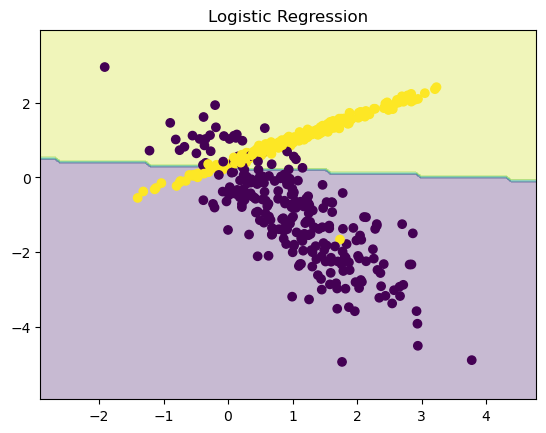

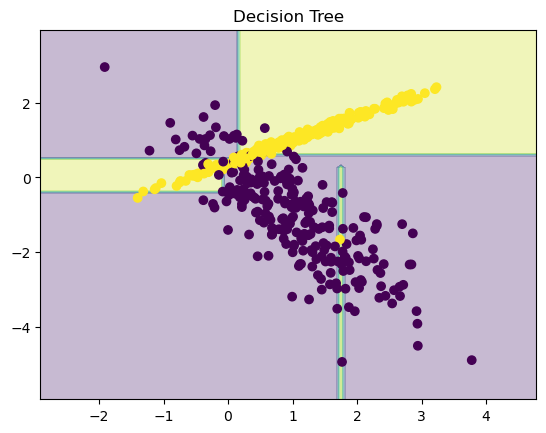

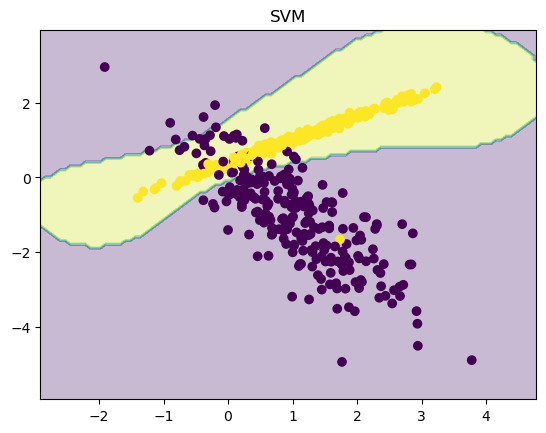

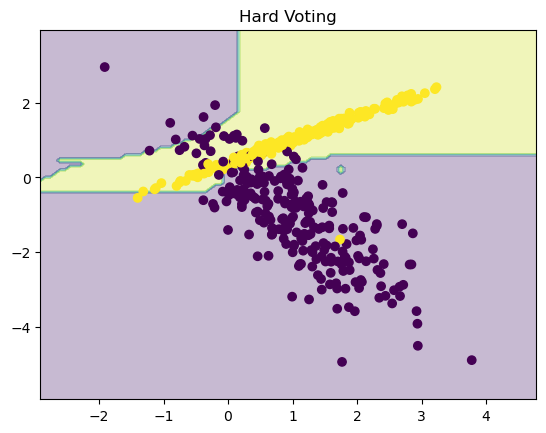

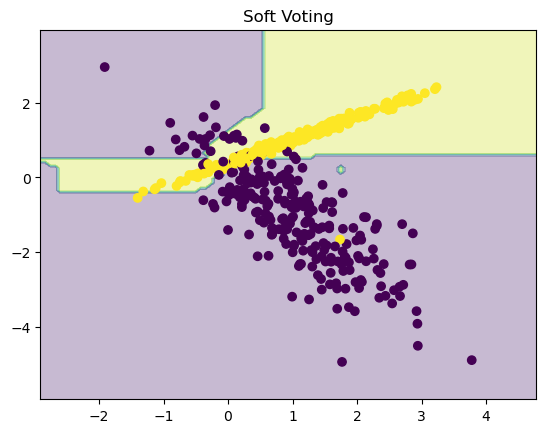

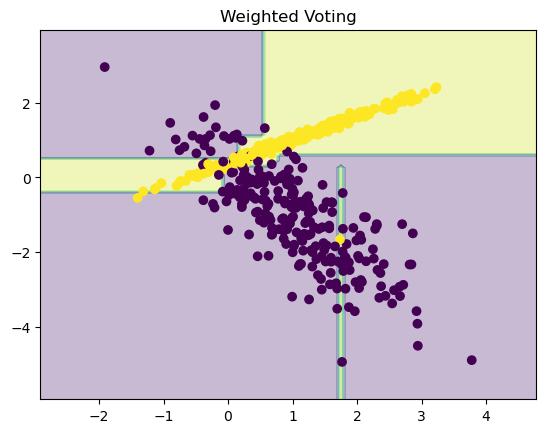

In [46]:
def plot_decision_boundary(model, X, y, title):
    x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
    
    xx, yy = np.meshgrid(np.linspace(x_min, x_max, 100),
                         np.linspace(y_min, y_max, 100))
    
    Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)

    plt.figure()
    plt.contourf(xx, yy, Z, alpha=0.3)
    plt.scatter(X[:, 0], X[:, 1], c=y)
    plt.title(title)
    plt.show()


# Plot all
plot_decision_boundary(model1, X, y, "Logistic Regression")
plot_decision_boundary(model2, X, y, "Decision Tree")
plot_decision_boundary(model3, X, y, "SVM")

plot_decision_boundary(hard_vote, X, y, "Hard Voting")
plot_decision_boundary(soft_vote, X, y, "Soft Voting")
plot_decision_boundary(weighted_vote, X, y, "Weighted Voting")